# **Proyecto 1**
## Competencia de Modelación 
### Deep Learning y sistemas inteligentes
Melisa Dayana Mendizabal Meléndez 23778

## Cómo está organizado este notebook

Este notebook documenta el proceso completo de modelación
- EDA 
- preprocesamiento 
- definición del MLP 
- búsqueda de hiperparámetros (varias rondas) 
- selección automática del mejor modelo 
- comparación contra una regresión lineal de referencia 
- análisis de residuos 
- exportación del modelo final para el día de la competencia.

Cada ronda de búsqueda de hiperparámetros queda registrada en una tabla resumen (sección "Consolidado de iteraciones"). 

# **Análisis exploratorio**
## Carga del dataset

Con esta vista inicial del set de datos se puede intuir que este contiene información sobre los detalles de casas y el precio de las mismas.

In [233]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('train.csv')
print(df.head())

     Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   255          20       RL         70.0     8400   Pave   NaN      Reg   
1  1067          60       RL         59.0     7837   Pave   NaN      IR1   
2   639          30       RL         67.0     8777   Pave   NaN      Reg   
3   800          50       RL         60.0     7200   Pave   NaN      Reg   
4   381          50       RL         50.0     5000   Pave  Pave      Reg   

  LandContour Utilities  ... PoolArea PoolQC  Fence MiscFeature MiscVal  \
0         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
1         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
2         Lvl    AllPub  ...        0    NaN  MnPrv         NaN       0   
3         Lvl    AllPub  ...        0    NaN  MnPrv         NaN       0   
4         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   

  MoSold YrSold  SaleType  SaleCondition  SalePrice  
0      6   2010        WD         Norm

## Dimensiones del dataset

In [234]:
filas = df.shape[0]
columnas = df.shape[1]
print(f'El dataset cuenta con {columnas} variables y con {filas} filas')


El dataset cuenta con 81 variables y con 1168 filas


## Tipos de variables (numéricas, categóricas, ordinales) y variable objetivo

Existen 80 variables, siendo la variable objetivo SalePrice que se almacena el precio de venta de la casa que se presenta. El resto de las variables muestra condiciones que afectan el precio de la casa como el vecindario, tamaño de las habitaciones, si esta cuenta con piscina y demás.

In [235]:
columnas = df.columns
columnas

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

### Listado de las variables junto con el tipo de dato que almacena. 

In [236]:
df.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

### Separación por tipo de variables

In [237]:
numericas_continuas = df.select_dtypes(include=['float64']).columns.tolist()
numericas_discretas = df.select_dtypes(include=['int64']).columns.tolist()
numericas =  df.select_dtypes(include=['float64','int64']).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()

print(f'Variables numéricas_continuas ({len(numericas_continuas)}):', numericas_continuas)
print()
print(f'Variables numéricas_discretas ({len(numericas_discretas)}):', numericas_discretas)
print()
print(f'Variables categóricas ({len(categoricas)}):', categoricas)

Variables numéricas_continuas (3): ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']

Variables numéricas_discretas (35): ['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Variables categóricas (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'Cent

## Estadísticas descriptivas
### Resumen de variables numéricas

In [238]:
df.describe(include=('int64', 'float64')).T[['mean','50%','std','min','max']]

,mean,50%,std,min,max
Id,730.904966,732.5,425.369088,1.0,1460.0
MSSubClass,56.849315,50.0,42.531862,20.0,190.0
LotFrontage,70.343849,70.0,24.897021,21.0,313.0
LotArea,10689.642123,9600.0,10759.366198,1300.0,215245.0
OverallQual,6.121575,6.0,1.367619,1.0,10.0
OverallCond,5.584760,5.0,1.116062,1.0,9.0
YearBuilt,1970.965753,1972.0,30.675495,1872.0,2010.0
YearRemodAdd,1984.897260,1994.0,20.733955,1950.0,2010.0
MasVnrArea,103.771945,0.0,173.032238,0.0,1378.0
BsmtFinSF1,446.023973,384.5,459.070977,0.0,5644.0


### Resumen de variables categóricas

In [239]:
df.describe(include='object').T

,count,unique,top,freq
MSZoning,1168,5,RL,924
Street,1168,2,Pave,1164
Alley,74,2,Grvl,44
LotShape,1168,4,Reg,729
LandContour,1168,4,Lvl,1059
Utilities,1168,2,AllPub,1167
LotConfig,1168,5,Inside,822
LandSlope,1168,3,Gtl,1108
Neighborhood,1168,25,NAmes,181
Condition1,1168,9,Norm,1004


### Categorías de variables categóricas

In [240]:
# Categóricas (moda, cuántas categorías únicas, frecuencia de la moda)
resumen_cat = pd.DataFrame({
    'n_categorias': df[categoricas].nunique(),
    'moda': df[categoricas].mode().iloc[0],
    'freq_moda': df[categoricas].apply(lambda x: x.value_counts().iloc[0])
})
resumen_cat.sort_values('n_categorias', ascending=False)

,n_categorias,moda,freq_moda
Neighborhood,25,NAmes,181
Exterior2nd,16,VinylSd,410
Exterior1st,15,VinylSd,420
SaleType,9,WD,1012
Condition1,9,Norm,1004
Condition2,8,Norm,1157
HouseStyle,8,1Story,577
Functional,7,Typ,1084
RoofMatl,7,CompShg,1149
BsmtFinType2,6,Unf,1009


## Identificación y tratamiento de valores nulos, atípicos (outliers) y posibles inconsistencias.

### Valores Nulos


In [241]:

nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
porcentaje = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({'nulos': nulos, 'porcentaje (%)': porcentaje})
resumen_nulos

,nulos,porcentaje (%)
PoolQC,1162,99.49
MiscFeature,1122,96.06
Alley,1094,93.66
Fence,935,80.05
MasVnrType,683,58.48
FireplaceQu,547,46.83
LotFrontage,217,18.58
GarageType,64,5.48
GarageYrBlt,64,5.48
GarageFinish,64,5.48


### Tratamiento de valores nulos

In [242]:
df_clean = df.copy()

# Grupo A: NaN significa "no tiene esa característica" rellenar con 'None' o 0
cat_none = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu','GarageType',
            'GarageFinish','GarageQual','GarageCond','BsmtQual','BsmtCond',
            'BsmtExposure','BsmtFinType1','BsmtFinType2','MasVnrType']
for col in cat_none:
    df_clean[col] = df_clean[col].fillna('None')

num_zero = ['GarageYrBlt','MasVnrArea']
for col in num_zero:
    df_clean[col] = df_clean[col].fillna(0)

# Grupo B: nulo genuino -> imputar con mediana por Neighborhood
df_clean['LotFrontage'] = df_clean.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# Electrical: 1 solo nulo -> moda
df_clean['Electrical'] = df_clean['Electrical'].fillna(df_clean['Electrical'].mode()[0])

print('Nulos restantes:', df_clean.isnull().sum().sum())

Nulos restantes: 0


In [243]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1168 entries, 0 to 1167
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   object 
 3   LotFrontage    1168 non-null   float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   object 
 6   Alley          1168 non-null   object 
 7   LotShape       1168 non-null   object 
 8   LandContour    1168 non-null   object 
 9   Utilities      1168 non-null   object 
 10  LotConfig      1168 non-null   object 
 11  LandSlope      1168 non-null   object 
 12  Neighborhood   1168 non-null   object 
 13  Condition1     1168 non-null   object 
 14  Condition2     1168 non-null   object 
 15  BldgType       1168 non-null   object 
 16  HouseStyle     1168 non-null   object 
 17  OverallQual    1168 non-null   int64  
 18  OverallC

### Valores atípicos

In [244]:
Q1, Q3 = df['SalePrice'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lim_inf, lim_sup = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers_price = df[(df['SalePrice'] < lim_inf) | (df['SalePrice'] > lim_sup)]
print(f'Outliers SalePrice (IQR): {len(outliers_price)} ({len(outliers_price)/len(df)*100:.1f}%)')

Outliers SalePrice (IQR): 48 (4.1%)


In [245]:
sospechosos = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
sospechosos[['GrLivArea','SalePrice','OverallQual','YearBuilt']]

,GrLivArea,SalePrice,OverallQual,YearBuilt
365,4676,184750,10,2007
495,5642,160000,10,2008


### Tratamiento de valores atípicos

In [246]:
df_clean = df_clean[~((df_clean['GrLivArea'] > 4000) & (df_clean['SalePrice'] < 300000))]
print('Filas tras remover outliers:', df_clean.shape[0])
print('Filas eliminadas', (filas - df_clean.shape[0]))

Filas tras remover outliers: 1166
Filas eliminadas 2


### Inconsistencias

In [247]:
# Ej: año de remodelación no puede ser anterior al año de construcción
inconsist1 = df[df['YearRemodAdd'] < df['YearBuilt']]
print('YearRemodAdd < YearBuilt:', len(inconsist1))

# Ej: GarageYrBlt no debería ser mayor a YrSold
inconsist2 = df[df['GarageYrBlt'] > df['YrSold']]
print('GarageYrBlt > YrSold:', len(inconsist2))

# Ej: casas con GarageCars=0 pero GarageArea>0 (o viceversa)
inconsist3 = df[(df['GarageCars'] == 0) & (df['GarageArea'] > 0)]
print('GarageCars=0 pero GarageArea>0:', len(inconsist3))

YearRemodAdd < YearBuilt: 0
GarageYrBlt > YrSold: 0
GarageCars=0 pero GarageArea>0: 0


## Visualizaciones
### Distribución de la variable objetivo

c:\Users\Usuario Preinstalado\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


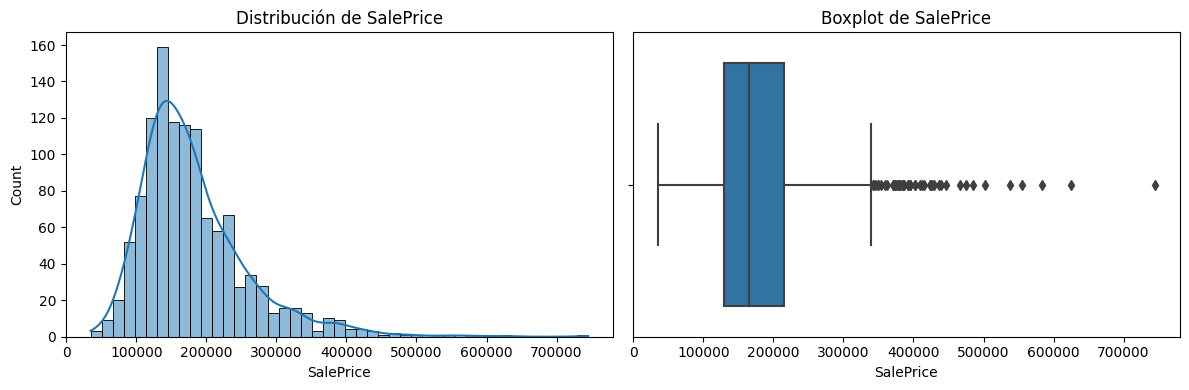

Skewness: 1.743128561420854


In [248]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('Distribución de SalePrice')

sns.boxplot(x=df['SalePrice'], ax=axes[1])
axes[1].set_title('Boxplot de SalePrice')
plt.tight_layout()
plt.show()

print('Skewness:', df['SalePrice'].skew())

### Correlaciones entre features

In [249]:
corr = df[numericas].corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
corr.head(15)

SalePrice       1.000000
OverallQual     0.785555
GrLivArea       0.695652
GarageCars      0.640991
GarageArea      0.624139
TotalBsmtSF     0.597766
1stFlrSF        0.587883
FullBath        0.552546
TotRmsAbvGrd    0.520388
YearBuilt       0.516501
YearRemodAdd    0.508593
GarageYrBlt     0.480351
MasVnrArea      0.459123
Fireplaces      0.457549
BsmtFinSF1      0.359460
Name: SalePrice, dtype: float64

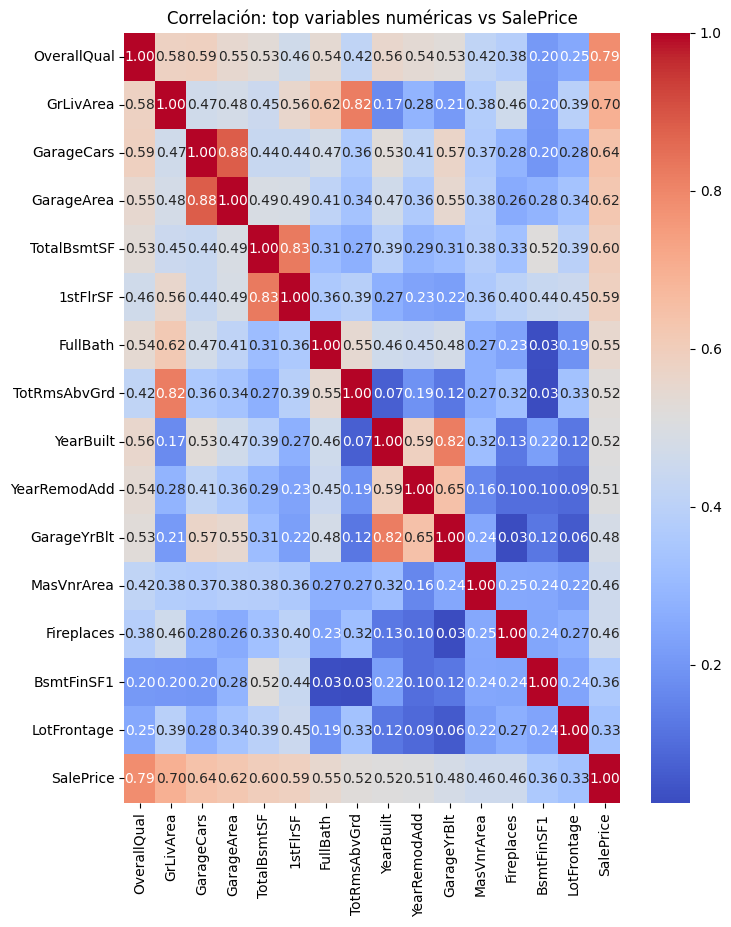

In [250]:
plt.figure(figsize=(8, 10))
top_corr = corr.drop('SalePrice').head(15).index
sns.heatmap(df[list(top_corr) + ['SalePrice']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlación: top variables numéricas vs SalePrice')
plt.show()

### Relación de cada feature con la variable objetivo

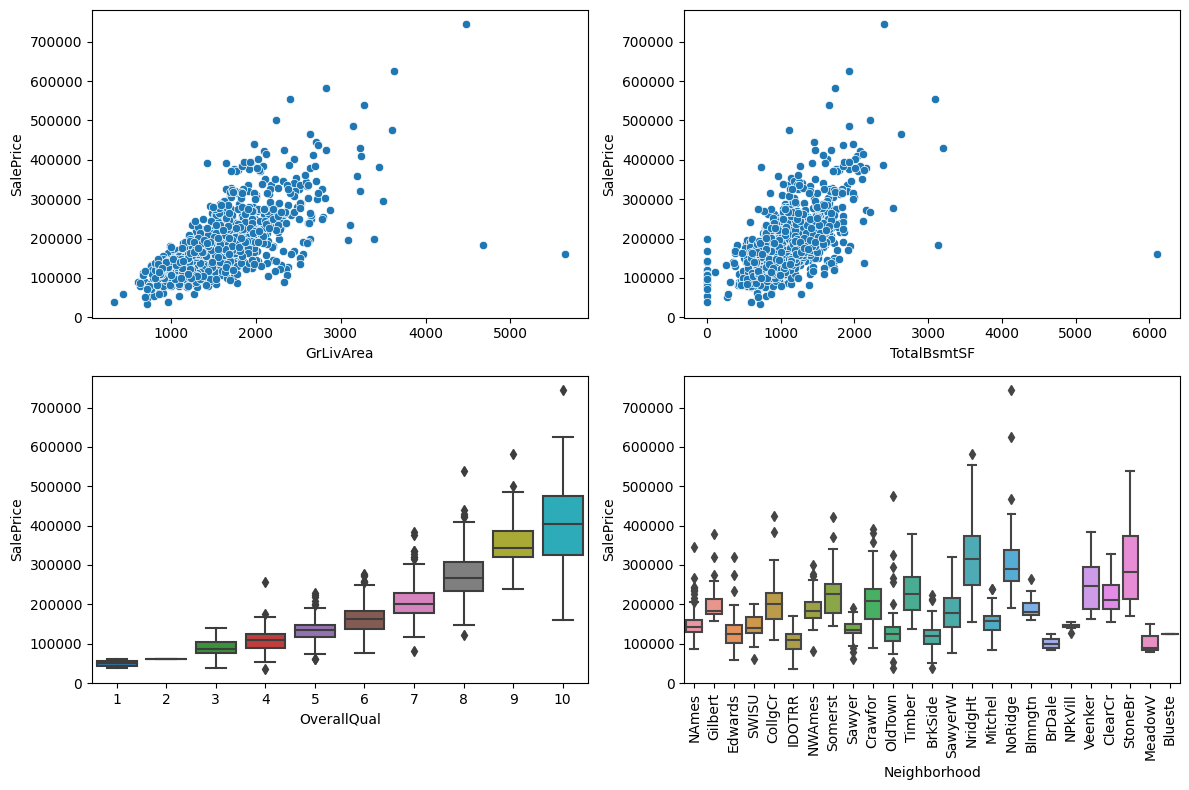

In [251]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df, ax=axes[0,0])
sns.scatterplot(x='TotalBsmtSF', y='SalePrice', data=df, ax=axes[0,1])
sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=axes[1,0])
sns.boxplot(x='Neighborhood', y='SalePrice', data=df, ax=axes[1,1])
axes[1,1].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

## Decisiones de preprocesamiento derivadas del EDA

### Encoding

In [252]:
# Encoding ordinal (mapeo manual, orden Po < Fa < TA < Gd < Ex)
mapa_calidad = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

cols_calidad = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC',
                'KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']

for col in cols_calidad:
    df_clean[col] = df_clean[col].map(mapa_calidad)

In [253]:
# El resto de ordinales con escalas propias (ajusta según lo que tengas)
mapa_bsmt_exposure = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
df_clean['BsmtExposure'] = df_clean['BsmtExposure'].map(mapa_bsmt_exposure)

mapa_bsmt_fin = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
df_clean['BsmtFinType1'] = df_clean['BsmtFinType1'].map(mapa_bsmt_fin)
df_clean['BsmtFinType2'] = df_clean['BsmtFinType2'].map(mapa_bsmt_fin)

In [254]:
# One-hot para las nominales restantes
categoricas_nominales_restantes = df_clean.select_dtypes(include='object').columns.tolist()
print('Nominales a codificar:', categoricas_nominales_restantes)

df_encoded = pd.get_dummies(df_clean, columns=categoricas_nominales_restantes, drop_first=True)
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print('Shape tras one-hot:', df_encoded.shape)

Nominales a codificar: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Shape tras one-hot: (1166, 215)


In [255]:
df_encoded.columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'ExterQual',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=215)

# Metodología de desarrollo
## Estrategia de división de datos 

In [256]:
# Separar X, y ANTES de escalar (para no tocar el target)
ids = df_encoded['Id'].copy()

X = df_encoded.drop(columns=['SalePrice', 'Id'])
y = df_encoded['SalePrice']

### Transformación del target

Se identificó en el análisis exploratorio que SalePrice presenta un sesgo positivo (skewness = 1.74), con una distribución de cola larga hacia la derecha. 
Se decidió aplicar log1p a SalePrice para reducir el sesgo y mejorar la convergencia del MLP.

In [257]:
y_log = np.log1p(y)

## Estrategia de división de datos

In [258]:
# Normalización — SOLO fit con train, nunca con val/test
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# Split 70/15/15: primero separamos el test (15%), luego dividimos el resto en train/val
X_temp, X_test, y_temp, y_test = train_test_split(X, y_log, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)
# 0.1765 del 85% restante ≈ 15% del total
print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)

Train: (816, 213) Val: (175, 213) Test: (175, 213)


### Normalización
Train para ajustar pesos, val para decidir hiperparámetros y aplicar early stopping durante el desarrollo (evita ver el test), test como evaluación final e insesgada antes de la competencia, simula qué tan bien generalizaría con datos nunca vistos.

In [259]:
# Normalización — fit SOLO con train
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

### Preparar los datos para PyTorch


In [260]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Usando:', device)

class HousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values if hasattr(y, 'values') else y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = HousingDataset(X_train_scaled, y_train)
val_ds = HousingDataset(X_val_scaled, y_val)
test_ds = HousingDataset(X_test_scaled, y_test)

batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

Usando: cpu


## Técnicas de regularización utilizadas
- Dropout (0.3): apaga aleatoriamente 30% de neuronas en cada paso de entrenamiento, evita que la red dependa demasiado de neuronas específicas (overfitting).
- BatchNorm1d: normaliza las activaciones dentro de la red, estabiliza y acelera el entrenamiento.
- Weight decay: lo agregamos en el optimizador (siguiente paso) — es regularización L2, penaliza pesos muy grandes.
- Early stopping: lo implementamos en el loop de entrenamiento (más abajo) — detiene el entrenamiento si val_loss deja de mejorar, evitando overfitting por sobre-entrenar.

In [261]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.BatchNorm1d(h))   # batch normalization
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))  # dropout
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))  # capa de salida (regresión)
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

input_dim = X_train_scaled.shape[1]
model = MLP(input_dim=input_dim, hidden_dims=[128, 64, 32], dropout=0.3).to(device)
print(model)

MLP(
  (model): Sequential(
    (0): Linear(in_features=213, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Función de pérdida, optimizador, tasa de aprendizaje y demás hiperparámetros

In [262]:
criterion = nn.MSELoss()  # RMSE = sqrt(MSE), así que entrenamos con MSE y sacamos raíz al reportar

learning_rate = 1e-3
weight_decay = 1e-4  # regularización L2

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Opcional: reduce el learning rate si el val_loss se estanca
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

### Loop de entrenamiento con early stopping

In [263]:
import numpy as np

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None,
                 max_epochs=200, patience=15):
    best_val_loss = float('inf')
    epochs_sin_mejora = 0
    best_model_state = None
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(max_epochs):
        # --- entrenamiento ---
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # --- validación ---
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = model(X_batch)
                loss = criterion(preds, y_batch)
                val_losses.append(loss.item())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if scheduler:
            scheduler.step(val_loss)

        # --- early stopping ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            epochs_sin_mejora = 0
        else:
            epochs_sin_mejora += 1

        if epoch % 10 == 0:
            print(f'Epoch {epoch}: train_RMSE={np.sqrt(train_loss):.4f}, val_RMSE={np.sqrt(val_loss):.4f}')

        if epochs_sin_mejora >= patience:
            print(f'Early stopping en epoch {epoch}')
            break

    model.load_state_dict(best_model_state)  # nos quedamos con el mejor modelo
    return model, history

model, history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler)

Epoch 0: train_RMSE=11.9473, val_RMSE=11.8130
Epoch 10: train_RMSE=6.5409, val_RMSE=6.8411
Epoch 20: train_RMSE=2.4158, val_RMSE=1.5235
Epoch 30: train_RMSE=2.2025, val_RMSE=1.0386
Epoch 40: train_RMSE=2.0447, val_RMSE=1.0715
Early stopping en epoch 49


# Búsqueda de hiperparámetros (iteraciones del modelo)

A continuación se documentan las distintas rondas de búsqueda realizadas para encontrar la mejor arquitectura y configuración de hiperparámetros del MLP. Cada ronda evalúa varias combinaciones sobre el conjunto de validación (nunca sobre test) y registra el RMSE obtenido. Todas las rondas se consolidan más adelante en una sola tabla, de la cual se selecciona automáticamente la mejor combinación.


Prueba todas las combinaciones de hiperparámetros en param_grid.

param_grid es un diccionario, ej:

- 'hidden_dims': [[64,32], [128,64,32], [256,128,64]],

- 'dropout': [0.2, 0.3, 0.4],

- 'learning_rate': [1e-3, 5e-4],

- 'weight_decay': [1e-4, 1e-5],




In [264]:
import itertools
import random

def set_seed(seed):
    #Fija la semilla para que los resultados sean reproducibles.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def grid_search(X_train, y_train, X_val, y_val, param_grid, seed=42, max_epochs=150, patience=15):
    
    set_seed(seed)

    keys = list(param_grid.keys())
    combinaciones = list(itertools.product(*param_grid.values()))
    print(f'Probando {len(combinaciones)} combinaciones con semilla {seed}...\n')

    resultados = []

    train_loader = DataLoader(HousingDataset(X_train, y_train), batch_size=32, shuffle=True)
    val_loader = DataLoader(HousingDataset(X_val, y_val), batch_size=32, shuffle=False)

    for combo in combinaciones:
        params = dict(zip(keys, combo))

        set_seed(seed)  # misma semilla en cada combinación, para comparar "parejo"

        model = MLP(input_dim=X_train.shape[1],
                    hidden_dims=params['hidden_dims'],
                    dropout=params['dropout']).to(device)

        optimizer = torch.optim.Adam(model.parameters(),
                                      lr=params['learning_rate'],
                                      weight_decay=params['weight_decay'])

        model, history = train_model(model, train_loader, val_loader,
                                      nn.MSELoss(), optimizer,
                                      max_epochs=max_epochs, patience=patience)

        mejor_val_rmse = np.sqrt(min(history['val_loss']))
        epoca_optima = np.argmin(history['val_loss'])

        resultados.append({**params, 'val_rmse': mejor_val_rmse, 'mejor_epoca': epoca_optima, 'history': history})
        print(f'{params} -> val_RMSE={mejor_val_rmse:.4f} (mejor época: {epoca_optima})')

    resultados_df = pd.DataFrame(resultados).sort_values('val_rmse')
    return resultados_df

## Funcion para graficas del mejor modelo

In [265]:
def plot_history(history, titulo='Curva de entrenamiento'):
    plt.figure(figsize=(8, 5))
    plt.plot(np.sqrt(history['train_loss']), label='Train RMSE')
    plt.plot(np.sqrt(history['val_loss']), label='Val RMSE')
    mejor_epoca = np.argmin(history['val_loss'])
    plt.axvline(mejor_epoca, color='green', linestyle='--', alpha=0.6, label=f'Mejor época ({mejor_epoca})')
    plt.xlabel('Época'); 
    plt.ylabel('RMSE'); 
    plt.title(titulo)
    plt.legend(); 
    plt.show()

### Ronda 1: grid search con distintas semillas

Se corre la misma grilla de hiperparámetros (arquitectura, dropout, learning rate, weight decay) con tres semillas distintas (42, 99, 23). El objetivo es verificar que la combinación ganadora no dependa de la inicialización aleatoria, sino que sea consistentemente buena. 

In [266]:
from IPython.display import display

param_grid = {
    'hidden_dims': [[64, 32], [128, 64, 32], [128, 64]],
    'dropout': [0.2, 0.3],
    'learning_rate': [1e-3, 5e-4],
    'weight_decay': [1e-4, 1e-5],
}

#El numero de las semillas fue seleccionado por criterio arbitrarios
# El más común usado, mi número favorito y el día de mi cumpleaños
semillas = [42, 99, 23]
resultados_por_semilla = {}

for s in semillas:
    print(f'\n=== Grid search con semilla {s} ===')
    resultados_por_semilla[s] = grid_search(X_train_scaled, y_train, X_val_scaled, y_val, param_grid, seed=s)

for s in semillas:
    print(f'\nTop 5 - semilla {s}:')
    display(resultados_por_semilla[s].head(5)[['hidden_dims','dropout','learning_rate','weight_decay','val_rmse']])


=== Grid search con semilla 42 ===
Probando 24 combinaciones con semilla 42...

Epoch 0: train_RMSE=12.1580, val_RMSE=11.9425
Epoch 10: train_RMSE=6.4402, val_RMSE=6.2790
Epoch 20: train_RMSE=1.8285, val_RMSE=1.3902
Epoch 30: train_RMSE=1.6380, val_RMSE=0.9499
Epoch 40: train_RMSE=1.6708, val_RMSE=0.8414
Epoch 50: train_RMSE=1.5635, val_RMSE=0.8978
Early stopping en epoch 56
{'hidden_dims': [64, 32], 'dropout': 0.2, 'learning_rate': 0.001, 'weight_decay': 0.0001} -> val_RMSE=0.7686 (mejor época: 41)
Epoch 0: train_RMSE=12.1580, val_RMSE=11.9409
Epoch 10: train_RMSE=6.4337, val_RMSE=6.3129
Epoch 20: train_RMSE=1.8174, val_RMSE=1.3013
Epoch 30: train_RMSE=1.6502, val_RMSE=0.8730
Epoch 40: train_RMSE=1.6645, val_RMSE=0.7713
Epoch 50: train_RMSE=1.5740, val_RMSE=0.8345
Epoch 60: train_RMSE=1.5741, val_RMSE=0.8615
Early stopping en epoch 61
{'hidden_dims': [64, 32], 'dropout': 0.2, 'learning_rate': 0.001, 'weight_decay': 1e-05} -> val_RMSE=0.7259 (mejor época: 46)
Epoch 0: train_RMSE=12.25

,hidden_dims,dropout,learning_rate,weight_decay,val_rmse
8,"[128, 64, 32]",0.2,0.0010,0.00010,0.331565
9,"[128, 64, 32]",0.2,0.0010,0.00001,0.405606
10,"[128, 64, 32]",0.2,0.0005,0.00010,0.537249
16,"[128, 64]",0.2,0.0010,0.00010,0.582939
13,"[128, 64, 32]",0.3,0.0010,0.00001,0.637199



Top 5 - semilla 99:


,hidden_dims,dropout,learning_rate,weight_decay,val_rmse
8,"[128, 64, 32]",0.2,0.0010,0.00010,0.330061
9,"[128, 64, 32]",0.2,0.0010,0.00001,0.415253
10,"[128, 64, 32]",0.2,0.0005,0.00010,0.485499
11,"[128, 64, 32]",0.2,0.0005,0.00001,0.542831
17,"[128, 64]",0.2,0.0010,0.00001,0.623945



Top 5 - semilla 23:


,hidden_dims,dropout,learning_rate,weight_decay,val_rmse
13,"[128, 64, 32]",0.3,0.0010,0.00001,0.421625
12,"[128, 64, 32]",0.3,0.0010,0.00010,0.467887
9,"[128, 64, 32]",0.2,0.0010,0.00001,0.480437
8,"[128, 64, 32]",0.2,0.0010,0.00010,0.485011
11,"[128, 64, 32]",0.2,0.0005,0.00001,0.507933


### Curva de la mejor combinación de la ronda 1 (semilla 42, como referencia)

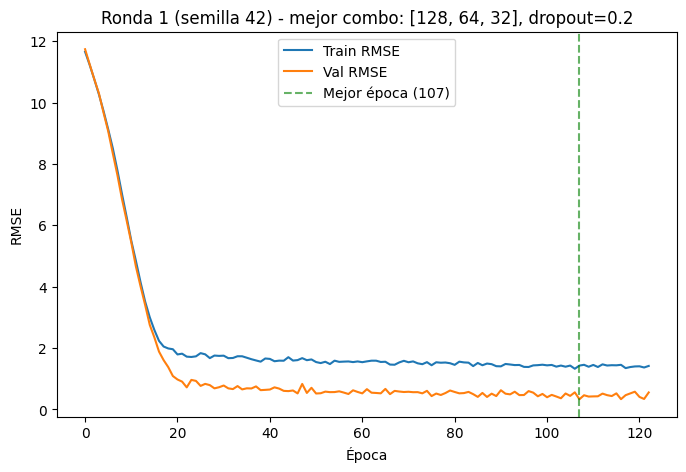

In [267]:

mejor_combo_r1 = resultados_por_semilla[42].iloc[0]
plot_history(mejor_combo_r1['history'],
             titulo=f"Ronda 1 (semilla 42) - mejor combo: {mejor_combo_r1['hidden_dims']}, dropout={mejor_combo_r1['dropout']}")

## Ronda 2: grid ampliado

A partir de lo observado en la ronda 1, se prueba una grilla más amplia: arquitecturas más grandes y valores de dropout más finos, buscando si hay margen para mejorar sobre la ronda 1.

In [268]:
param_space_ampliado = {
    'hidden_dims': [[128,64,32], [256,128,64], [256,128,64,32]],
    'dropout': [0.1, 0.15, 0.2, 0.25],
    'learning_rate': [1e-3, 2e-3, 5e-4],
    'weight_decay': [1e-4, 5e-4, 1e-5],
}
resultados_ampliado = grid_search(X_train_scaled, y_train, X_val_scaled, y_val, param_space_ampliado, seed=23)
resultados_ampliado.head(10)[['hidden_dims','dropout','learning_rate','weight_decay','val_rmse']]

Probando 108 combinaciones con semilla 23...

Epoch 0: train_RMSE=11.4842, val_RMSE=11.4875
Epoch 10: train_RMSE=5.0760, val_RMSE=4.8184
Epoch 20: train_RMSE=1.2138, val_RMSE=0.7527
Epoch 30: train_RMSE=1.1012, val_RMSE=0.4163
Epoch 40: train_RMSE=1.0910, val_RMSE=0.4381
Early stopping en epoch 45
{'hidden_dims': [128, 64, 32], 'dropout': 0.1, 'learning_rate': 0.001, 'weight_decay': 0.0001} -> val_RMSE=0.4163 (mejor época: 30)
Epoch 0: train_RMSE=11.4842, val_RMSE=11.4827
Epoch 10: train_RMSE=5.1872, val_RMSE=4.9294
Epoch 20: train_RMSE=1.1530, val_RMSE=0.8283
Epoch 30: train_RMSE=1.1269, val_RMSE=0.4909
Epoch 40: train_RMSE=1.0880, val_RMSE=0.4444
Epoch 50: train_RMSE=1.0474, val_RMSE=0.5345
Epoch 60: train_RMSE=1.0566, val_RMSE=0.4683
Epoch 70: train_RMSE=1.1084, val_RMSE=0.4655
Epoch 80: train_RMSE=0.9501, val_RMSE=0.3253
Epoch 90: train_RMSE=0.9792, val_RMSE=0.3760
Epoch 100: train_RMSE=0.9432, val_RMSE=0.3406
Early stopping en epoch 108
{'hidden_dims': [128, 64, 32], 'dropout': 0.

,hidden_dims,dropout,learning_rate,weight_decay,val_rmse
76,"[256, 128, 64, 32]",0.10,0.002,0.00050,0.180899
75,"[256, 128, 64, 32]",0.10,0.002,0.00010,0.197658
77,"[256, 128, 64, 32]",0.10,0.002,0.00001,0.202841
41,"[256, 128, 64]",0.10,0.002,0.00001,0.220586
73,"[256, 128, 64, 32]",0.10,0.001,0.00050,0.233971
5,"[128, 64, 32]",0.10,0.002,0.00001,0.238270
74,"[256, 128, 64, 32]",0.10,0.001,0.00001,0.252525
40,"[256, 128, 64]",0.10,0.002,0.00050,0.258801
85,"[256, 128, 64, 32]",0.15,0.002,0.00050,0.262013
50,"[256, 128, 64]",0.15,0.002,0.00001,0.264718


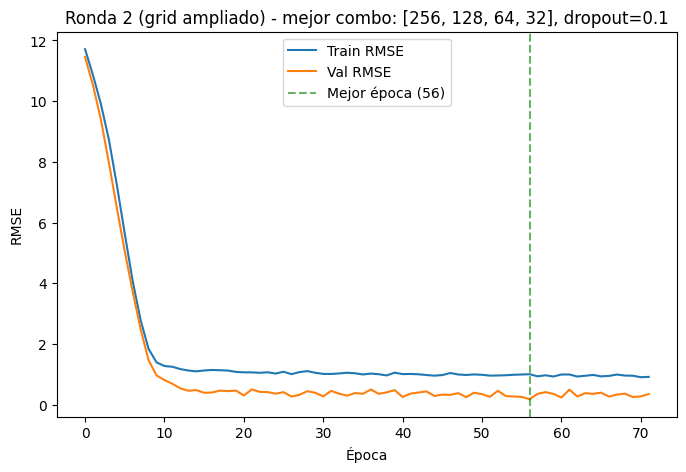

In [269]:
mejor_combo_r2 = resultados_ampliado.iloc[0]
plot_history(mejor_combo_r2['history'],
             titulo=f"Ronda 2 (grid ampliado) - mejor combo: {mejor_combo_r2['hidden_dims']}, dropout={mejor_combo_r2['dropout']}")

## Ronda 3: greedy search

En vez de probar todas las combinaciones (costoso), el greedy search ajusta un hiperparámetro a la vez, dejando fijos los demás en el mejor valor encontrado hasta el momento. Es más rápido, aunque puede quedar atrapado en un óptimo local. Se corre con dos espacios de búsqueda distintos para comparar (antes las dos corridas se sobreescribían entre sí porque usaban las mismas variables; aquí cada una queda guardada por separado).

In [270]:
def greedy_search(X_train, y_train, X_val, y_val, param_space, orden, seed=42, max_epochs=150, patience=15):
    set_seed(seed)
    train_loader_local = DataLoader(HousingDataset(X_train, y_train), batch_size=32, shuffle=True)
    val_loader_local = DataLoader(HousingDataset(X_val, y_val), batch_size=32, shuffle=False)

    mejores_params = {k: v[0] for k, v in param_space.items()}
    historial_busqueda = []

    for hp in orden:
        print(f'\n--- Ajustando: {hp} ---')
        mejor_rmse_local = float('inf')
        mejor_valor = mejores_params[hp]

        for valor in param_space[hp]:
            params_prueba = mejores_params.copy()
            params_prueba[hp] = valor

            set_seed(seed)
            model = MLP(input_dim=X_train.shape[1],
                        hidden_dims=params_prueba['hidden_dims'],
                        dropout=params_prueba['dropout']).to(device)
            optimizer = torch.optim.Adam(model.parameters(),
                                          lr=params_prueba['learning_rate'],
                                          weight_decay=params_prueba['weight_decay'])
            model, history = train_model(model, train_loader_local, val_loader_local,
                                          nn.MSELoss(), optimizer,
                                          max_epochs=max_epochs, patience=patience)
            rmse = np.sqrt(min(history['val_loss']))
            print(f'  {hp}={valor} -> val_RMSE={rmse:.4f}')

            historial_busqueda.append({**params_prueba, 'val_rmse': rmse, 'history': history})

            if rmse < mejor_rmse_local:
                mejor_rmse_local = rmse
                mejor_valor = valor

        mejores_params[hp] = mejor_valor
        print(f'  >> Mejor {hp}: {mejor_valor} (RMSE={mejor_rmse_local:.4f})')

    historial_df = pd.DataFrame(historial_busqueda).sort_values('val_rmse').reset_index(drop=True)
    return mejores_params, historial_df

### Greedy - espacio de búsqueda 1


--- Ajustando: hidden_dims ---
Epoch 0: train_RMSE=12.1499, val_RMSE=11.9271
Epoch 10: train_RMSE=6.2261, val_RMSE=6.0730
Epoch 20: train_RMSE=1.4212, val_RMSE=1.2255
Epoch 30: train_RMSE=1.1676, val_RMSE=0.7576
Epoch 40: train_RMSE=1.1888, val_RMSE=0.6935
Epoch 50: train_RMSE=1.1504, val_RMSE=0.6867
Epoch 60: train_RMSE=1.1293, val_RMSE=0.6678
Epoch 70: train_RMSE=1.1190, val_RMSE=0.5749
Epoch 80: train_RMSE=1.1094, val_RMSE=0.6809
Epoch 90: train_RMSE=1.0682, val_RMSE=0.6446
Epoch 100: train_RMSE=1.1056, val_RMSE=0.5701
Early stopping en epoch 109
  hidden_dims=[64, 32] -> val_RMSE=0.5461
Epoch 0: train_RMSE=11.6522, val_RMSE=11.6914
Epoch 10: train_RMSE=5.3082, val_RMSE=5.1405
Epoch 20: train_RMSE=1.4157, val_RMSE=0.8137
Epoch 30: train_RMSE=1.1911, val_RMSE=0.6406
Epoch 40: train_RMSE=1.1276, val_RMSE=0.5080
Epoch 50: train_RMSE=1.1199, val_RMSE=0.4212
Epoch 60: train_RMSE=1.0578, val_RMSE=0.3845
Epoch 70: train_RMSE=1.0883, val_RMSE=0.3680
Epoch 80: train_RMSE=1.0117, val_RMSE=0.

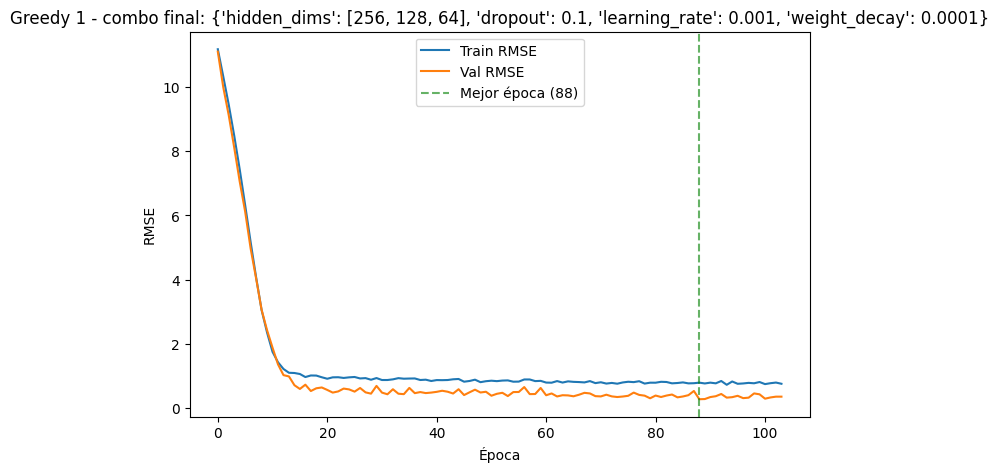

In [271]:
param_space_g1 = {
    'hidden_dims': [[64,32], [128,64,32], [256,128,64]],
    'dropout': [0.1, 0.2, 0.3],
    'learning_rate': [1e-3, 5e-4],
    'weight_decay': [1e-4, 1e-5],
}
orden = ['hidden_dims', 'dropout', 'learning_rate', 'weight_decay']

mejores_params_g1, historial_g1 = greedy_search(X_train_scaled, y_train, X_val_scaled, y_val, param_space_g1, orden, seed=42)
print('\nMejores hiperparámetros (greedy 1):', mejores_params_g1)

set_seed(42)
model_greedy1 = MLP(input_dim=X_train_scaled.shape[1],
                     hidden_dims=mejores_params_g1['hidden_dims'],
                     dropout=mejores_params_g1['dropout']).to(device)
optimizer_g1 = torch.optim.Adam(model_greedy1.parameters(),
                                 lr=mejores_params_g1['learning_rate'],
                                 weight_decay=mejores_params_g1['weight_decay'])
model_greedy1, history_greedy1 = train_model(model_greedy1, train_loader, val_loader,
                                              nn.MSELoss(), optimizer_g1, max_epochs=150, patience=15)

plot_history(history_greedy1, titulo=f"Greedy 1 - combo final: {mejores_params_g1}")

### Greedy - espacio de búsqueda 2 (redes más grandes)


--- Ajustando: hidden_dims ---
Epoch 0: train_RMSE=11.6522, val_RMSE=11.6914
Epoch 10: train_RMSE=5.3082, val_RMSE=5.1405
Epoch 20: train_RMSE=1.4157, val_RMSE=0.8137
Epoch 30: train_RMSE=1.1911, val_RMSE=0.6406
Epoch 40: train_RMSE=1.1276, val_RMSE=0.5080
Epoch 50: train_RMSE=1.1199, val_RMSE=0.4212
Epoch 60: train_RMSE=1.0578, val_RMSE=0.3845
Epoch 70: train_RMSE=1.0883, val_RMSE=0.3680
Epoch 80: train_RMSE=1.0117, val_RMSE=0.3555
Epoch 90: train_RMSE=1.0770, val_RMSE=0.4872
Early stopping en epoch 93
  hidden_dims=[128, 64, 32] -> val_RMSE=0.3092
Epoch 0: train_RMSE=11.1805, val_RMSE=11.1063
Epoch 10: train_RMSE=1.7516, val_RMSE=1.8822
Epoch 20: train_RMSE=0.9138, val_RMSE=0.5654
Epoch 30: train_RMSE=0.8741, val_RMSE=0.4818
Epoch 40: train_RMSE=0.8719, val_RMSE=0.5057
Epoch 50: train_RMSE=0.8527, val_RMSE=0.3846
Epoch 60: train_RMSE=0.7946, val_RMSE=0.3991
Epoch 70: train_RMSE=0.8042, val_RMSE=0.3631
Epoch 80: train_RMSE=0.7903, val_RMSE=0.3903
Epoch 90: train_RMSE=0.7922, val_RMSE

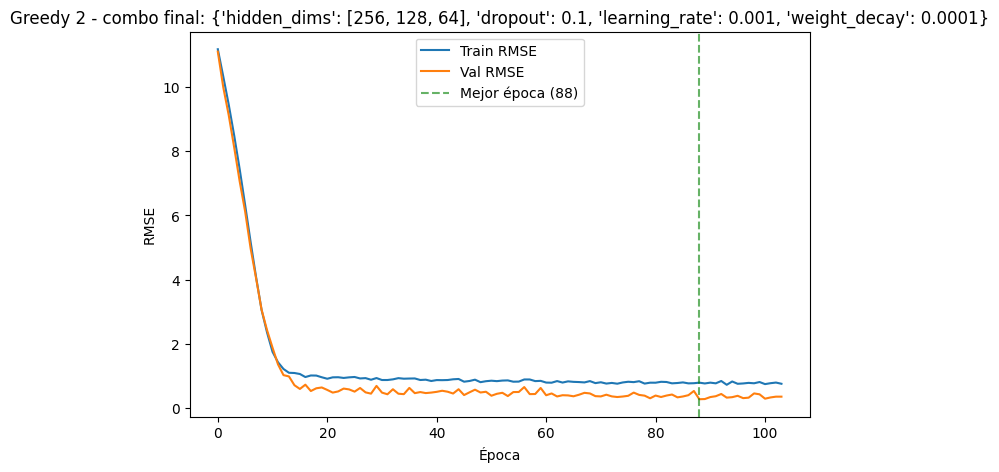

In [272]:
param_space_g2 = {
    'hidden_dims': [[128,64,32], [256,128,64], [256,128,64,32]],
    'dropout': [0.1, 0.15, 0.2, 0.25],
    'learning_rate': [1e-3, 2e-3, 5e-4],
    'weight_decay': [1e-4, 5e-4, 1e-5],
}

mejores_params_g2, historial_g2 = greedy_search(X_train_scaled, y_train, X_val_scaled, y_val, param_space_g2, orden, seed=42)
print('\nMejores hiperparámetros (greedy 2):', mejores_params_g2)

set_seed(42)
model_greedy2 = MLP(input_dim=X_train_scaled.shape[1],
                     hidden_dims=mejores_params_g2['hidden_dims'],
                     dropout=mejores_params_g2['dropout']).to(device)
optimizer_g2 = torch.optim.Adam(model_greedy2.parameters(),
                                 lr=mejores_params_g2['learning_rate'],
                                 weight_decay=mejores_params_g2['weight_decay'])
model_greedy2, history_greedy2 = train_model(model_greedy2, train_loader, val_loader,
                                              nn.MSELoss(), optimizer_g2, max_epochs=150, patience=15)

plot_history(history_greedy2, titulo=f"Greedy 2 - combo final: {mejores_params_g2}")

## Consolidado de todas las iteraciones

Se reúnen los resultados de las 6 corridas (3 semillas de grid search, grid ampliado, 2 greedy search) en una sola tabla, ordenada de menor a mayor RMSE de validación. El modelo final se construye automáticamente a partir de la fila con menor val_rmse_log de esta tabla, en vez de fijar a mano una combinación, así se evita el error de referenciar la variable equivocada.

In [273]:
iteraciones = pd.DataFrame([
    {'id': 1, 'descripcion': 'Grid search, semilla 42',
     **resultados_por_semilla[42].iloc[0][['hidden_dims','dropout','learning_rate','weight_decay']].to_dict(),
     'val_rmse_log': resultados_por_semilla[42].iloc[0]['val_rmse'],
     'history': resultados_por_semilla[42].iloc[0]['history']},
    {'id': 2, 'descripcion': 'Grid search, semilla 99',
     **resultados_por_semilla[99].iloc[0][['hidden_dims','dropout','learning_rate','weight_decay']].to_dict(),
     'val_rmse_log': resultados_por_semilla[99].iloc[0]['val_rmse'],
     'history': resultados_por_semilla[99].iloc[0]['history']},
    {'id': 3, 'descripcion': 'Grid search, semilla 23',
     **resultados_por_semilla[23].iloc[0][['hidden_dims','dropout','learning_rate','weight_decay']].to_dict(),
     'val_rmse_log': resultados_por_semilla[23].iloc[0]['val_rmse'],
     'history': resultados_por_semilla[23].iloc[0]['history']},
    {'id': 4, 'descripcion': 'Grid search ampliado (redes más grandes, dropout más fino)',
     **resultados_ampliado.iloc[0][['hidden_dims','dropout','learning_rate','weight_decay']].to_dict(),
     'val_rmse_log': resultados_ampliado.iloc[0]['val_rmse'],
     'history': resultados_ampliado.iloc[0]['history']},
    {'id': 5, 'descripcion': 'Greedy search - espacio 1',
     **mejores_params_g1,
     'val_rmse_log': np.sqrt(min(history_greedy1['val_loss'])),
     'history': history_greedy1},
    {'id': 6, 'descripcion': 'Greedy search - espacio 2 (redes más grandes)',
     **mejores_params_g2,
     'val_rmse_log': np.sqrt(min(history_greedy2['val_loss'])),
     'history': history_greedy2},
]).sort_values('val_rmse_log').reset_index(drop=True)

iteraciones[['id','descripcion','hidden_dims','dropout','learning_rate','weight_decay','val_rmse_log']]

,id,descripcion,hidden_dims,dropout,learning_rate,weight_decay,val_rmse_log
0,4,"Grid search ampliado (redes más grandes, dropo...","[256, 128, 64, 32]",0.1,0.002,0.00050,0.180899
1,5,Greedy search - espacio 1,"[256, 128, 64]",0.1,0.001,0.00010,0.275647
2,6,Greedy search - espacio 2 (redes más grandes),"[256, 128, 64]",0.1,0.001,0.00010,0.275647
3,2,"Grid search, semilla 99","[128, 64, 32]",0.2,0.001,0.00010,0.330061
4,1,"Grid search, semilla 42","[128, 64, 32]",0.2,0.001,0.00010,0.331565
5,3,"Grid search, semilla 23","[128, 64, 32]",0.3,0.001,0.00001,0.421625


In [274]:
# Selección automática de la mejor iteración (menor RMSE de validación, escala log)
mejor_iteracion = iteraciones.iloc[0]

print('Iteración ganadora:', mejor_iteracion['descripcion'])
print('Hiperparámetros:', {
    'hidden_dims': mejor_iteracion['hidden_dims'],
    'dropout': mejor_iteracion['dropout'],
    'learning_rate': mejor_iteracion['learning_rate'],
    'weight_decay': mejor_iteracion['weight_decay'],
})
print(f"val_RMSE (escala log): {mejor_iteracion['val_rmse_log']:.4f}")

Iteración ganadora: Grid search ampliado (redes más grandes, dropout más fino)
Hiperparámetros: {'hidden_dims': [256, 128, 64, 32], 'dropout': 0.1, 'learning_rate': 0.002, 'weight_decay': 0.0005}
val_RMSE (escala log): 0.1809


### Observaciones sobre las iteraciones
Observaciones calculadas directamente de la tabla de iteraciones (no fijadas a mano), para que el texto se mantenga correcto sin importar qué combinación termine ganando.

In [275]:
# Observaciones calculadas directamente de la tabla de iteraciones (no fijadas a mano),
# para que el texto se mantenga correcto sin importar qué combinación termine ganando.

print('--- Efecto del dropout ---')
for d in sorted(iteraciones['dropout'].unique()):
    prom = iteraciones.loc[iteraciones['dropout'] == d, 'val_rmse_log'].mean()
    print(f'RMSE promedio (val) con dropout={d}: {prom:.4f}')

print('\n--- Estabilidad entre semillas (ids 1, 2 y 3: mismo grid, distinta semilla) ---')
rmse_semillas = iteraciones[iteraciones['descripcion'].str.contains('semilla')]['val_rmse_log']
print(f'val_RMSE min={rmse_semillas.min():.4f}, max={rmse_semillas.max():.4f}, std={rmse_semillas.std():.4f}')
print('Una desviación estándar baja entre semillas indica que el resultado no depende demasiado de la inicialización aleatoria.')

print('\n--- Overfitting en la iteración ganadora ---')
h = mejor_iteracion['history']
train_final = np.sqrt(h['train_loss'][-1])
val_final = np.sqrt(h['val_loss'][-1])
print(f'train_RMSE final={train_final:.4f}, val_RMSE final={val_final:.4f}, brecha={val_final - train_final:.4f}')
print('Una brecha pequeña sugiere que dropout + weight decay + early stopping están controlando el overfitting.')

--- Efecto del dropout ---
RMSE promedio (val) con dropout=0.1: 0.2441
RMSE promedio (val) con dropout=0.2: 0.3308
RMSE promedio (val) con dropout=0.3: 0.4216

--- Estabilidad entre semillas (ids 1, 2 y 3: mismo grid, distinta semilla) ---
val_RMSE min=0.3301, max=0.4216, std=0.0524
Una desviación estándar baja entre semillas indica que el resultado no depende demasiado de la inicialización aleatoria.

--- Overfitting en la iteración ganadora ---
train_RMSE final=0.9164, val_RMSE final=0.3514, brecha=-0.5650
Una brecha pequeña sugiere que dropout + weight decay + early stopping están controlando el overfitting.


# Regresión lineal (modelo de referencia)

Se entrena una regresión lineal simple sobre los mismos datos preprocesados, para tener un punto de comparación básico: el MLP debería superarla si el pipeline y la búsqueda de hiperparámetros están bien hechos.

In [276]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)  # y_train ya está en escala log, igual que el MLP

preds_lr_log = lr_model.predict(X_test_scaled)
preds_lr_real = np.expm1(preds_lr_log)
y_test_real = np.expm1(y_test)

rmse_lr = np.sqrt(mean_squared_error(y_test_real, preds_lr_real))
print(f'RMSE regresión lineal (test, escala real): ${rmse_lr:,.2f}')

RMSE regresión lineal (test, escala real): $25,075.86


# Modelo Final


In [ ]:
set_seed(23)

modelo_final = MLP(input_dim=X_train_scaled.shape[1],
                    hidden_dims=mejor_iteracion['hidden_dims'],
                    dropout=mejor_iteracion['dropout']).to(device)
optimizer_f = torch.optim.Adam(modelo_final.parameters(),
                                lr=mejor_iteracion['learning_rate'],
                                weight_decay=mejor_iteracion['weight_decay'])
modelo_final, history_f = train_model(modelo_final, train_loader, val_loader,
                                       nn.MSELoss(), optimizer_f, max_epochs=200, patience=20)

# Evaluar en TEST (nunca antes tocado)
modelo_final.eval()
with torch.no_grad():
    preds_test_log = modelo_final(torch.tensor(X_test_scaled, dtype=torch.float32).to(device)).cpu().numpy().flatten()

preds_test_real = np.expm1(preds_test_log)
rmse_mlp = np.sqrt(mean_squared_error(y_test_real, preds_test_real))

print(f"Hiperparámetros usados: {mejor_iteracion[['hidden_dims','dropout','learning_rate','weight_decay']].to_dict()}")
print(f'RMSE MLP final (test, escala real): ${rmse_mlp:,.2f}')
print(f'RMSE regresión lineal (test, escala real): ${rmse_lr:,.2f}')
mejora = (1 - rmse_mlp / rmse_lr) * 100
print(f'Mejora del MLP sobre regresión lineal: {mejora:.1f}%')

if mejora < 0:
    print('\n⚠️ El MLP quedó por debajo de la regresión lineal. Si esto ocurre, revisar: que '
          '"mejor_iteracion" realmente sea la fila con menor val_rmse_log de la tabla de '
          'iteraciones, que el scaler y el orden de columnas usados coincidan con los de '
          'entrenamiento, y que no haya fuga de datos entre train/val/test.')

Epoch 0: train_RMSE=12.2953, val_RMSE=12.0061
Epoch 10: train_RMSE=1.6286, val_RMSE=1.3266
Epoch 20: train_RMSE=1.2218, val_RMSE=0.5879
Epoch 30: train_RMSE=1.1254, val_RMSE=0.5356
Epoch 40: train_RMSE=1.0765, val_RMSE=0.4506
Epoch 50: train_RMSE=1.0234, val_RMSE=0.3022
Epoch 60: train_RMSE=1.0090, val_RMSE=0.3985
Early stopping en epoch 61
Hiperparámetros usados: {'hidden_dims': [256, 128, 64, 32], 'dropout': 0.1, 'learning_rate': 0.002, 'weight_decay': 0.0005}
RMSE MLP final (test, escala real): $47,003.34
RMSE regresión lineal (test, escala real): $25,075.86
Mejora del MLP sobre regresión lineal: -87.4%

⚠️ El MLP quedó por debajo de la regresión lineal. Si esto ocurre, revisar: que "mejor_iteracion" realmente sea la fila con menor val_rmse_log de la tabla de iteraciones, que el scaler y el orden de columnas usados coincidan con los de entrenamiento, y que no haya fuga de datos entre train/val/test.


## Análisis de residuos del modelo final

c:\Users\Usuario Preinstalado\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


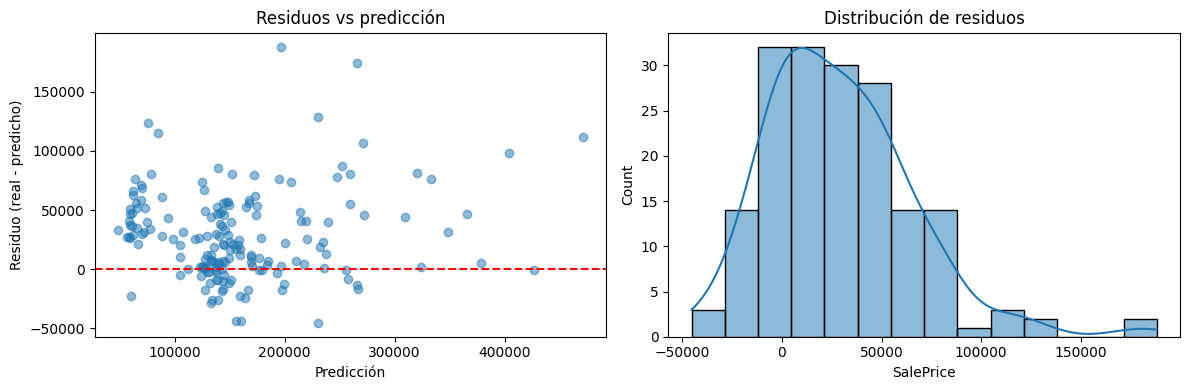

,real,prediccion,error_abs
920,385000.0,196962.734375,188037.265625
763,440000.0,265963.343750,174036.656250
960,359100.0,230124.531250,128975.468750
586,200100.0,76223.625000,123876.375000
792,200000.0,85034.843750,114965.156250
593,582933.0,471384.156250,111548.843750
359,377500.0,271046.093750,106453.906250
208,501837.0,403936.187500,97900.812500
260,339750.0,252422.328125,87327.671875
592,225000.0,139174.437500,85825.562500


In [278]:
residuos = y_test_real - preds_test_real

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.scatter(preds_test_real, residuos, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicción'); plt.ylabel('Residuo (real - predicho)')
plt.title('Residuos vs predicción')

plt.subplot(1,2,2)
sns.histplot(residuos, kde=True)
plt.title('Distribución de residuos')
plt.tight_layout(); plt.show()

# Casas donde el modelo falla más
df_test_errores = pd.DataFrame({'real': y_test_real, 'prediccion': preds_test_real, 'error_abs': np.abs(residuos)})
df_test_errores.sort_values('error_abs', ascending=False).head(10)

# Exportar el modelo final

In [279]:
export_dict = {
    # Arquitectura y pesos
    'model_state_dict': modelo_final.state_dict(),
    'input_dim': int(X_train_scaled.shape[1]),
    'hidden_dims': mejor_iteracion['hidden_dims'],
    'dropout': float(mejor_iteracion['dropout']),

    # Preprocesamiento (para poder aplicar exactamente el mismo pipeline al dataset de prueba)
    'scaler': scaler,
    'columnas_modelo': X.columns.tolist(),
    'neighborhood_lotfrontage_medians': df_clean.groupby('Neighborhood')['LotFrontage'].median().to_dict(),
    'electrical_mode': df_clean['Electrical'].mode()[0],
    'cat_none': cat_none,
    'num_zero': num_zero,
    'mapa_calidad': mapa_calidad,
    'cols_calidad': cols_calidad,
    'mapa_bsmt_exposure': mapa_bsmt_exposure,
    'mapa_bsmt_fin': mapa_bsmt_fin,

    # Metadata / trazabilidad
    'hiperparametros': mejor_iteracion[['hidden_dims','dropout','learning_rate','weight_decay']].to_dict(),
    'descripcion_iteracion_ganadora': mejor_iteracion['descripcion'],
    'test_rmse': float(rmse_mlp),
}

torch.save(export_dict, 'modelo_final_completo.pt')
print('Modelo y pipeline de preprocesamiento guardados en modelo_final_completo.pt')

Modelo y pipeline de preprocesamiento guardados en modelo_final_completo.pt


In [280]:
# Verificación: recargar el modelo y confirmar que reproduce las mismas predicciones sobre test
checkpoint = torch.load('modelo_final_completo.pt', weights_only=False)

modelo_verificacion = MLP(input_dim=checkpoint['input_dim'],
                           hidden_dims=checkpoint['hidden_dims'],
                           dropout=checkpoint['dropout']).to(device)
modelo_verificacion.load_state_dict(checkpoint['model_state_dict'])
modelo_verificacion.eval()

with torch.no_grad():
    preds_verif_log = modelo_verificacion(torch.tensor(X_test_scaled, dtype=torch.float32).to(device)).cpu().numpy().flatten()

preds_verif_real = np.expm1(preds_verif_log)
diferencia_max = np.abs(preds_verif_real - preds_test_real).max()
print(f'Diferencia máxima entre predicciones originales y recargadas: {diferencia_max:.6f}')
assert diferencia_max < 1e-3, 'El modelo recargado no coincide con el original'
print('OK: el modelo exportado reproduce exactamente las predicciones del modelo original.')

Diferencia máxima entre predicciones originales y recargadas: 0.000000
OK: el modelo exportado reproduce exactamente las predicciones del modelo original.
